<table class="tfo-notebook-buttons" align="left">
<td style="border: none;">
<a target="blank" href="https://colab.research.google.com/github/Hari31416/Portfolio/blob/main/Titanic/Final.ipynb?hl=en"><img src="https://colab.research.google.com/img/colab_favicon_256px.png" width="28" height="28"/>Run on Google Colab</a></td>
<td style="border: none;">
<a target="blank" href="https://github.com/Hari31416/Portfolio/blob/main/Titanic/Final.ipynb"><img src="https://cdn.icon-icons.com/icons2/2368/PNG/512/github_logo_icon_143772.png" width="28" height="28"/>View on Github</a></td>
<td style="border: none;">
</table>

# Preparation

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## loading the data

In [2]:
train = pd.read_csv('train_final.csv')
test = pd.read_csv('test_final.csv')

In [ ]:
train.head()

,Survived,Pclass,Sex,SibSp,Parch,FamilySize,Embarked_Q,Embarked_S,Title_Master,Title_Miss,...,Ticket_first_letter_7,Ticket_first_letter_X,Cabin_First_B,Cabin_First_C,Cabin_First_D,Cabin_First_E,Cabin_First_F,Cabin_First_N,Age,Fare
0,0,3,0,1,0,2,0,1,0,0,...,0,1,0,0,0,0,0,1,-0.565587,-0.502445
1,1,1,1,1,0,2,0,0,0,0,...,0,1,0,1,0,0,0,0,0.624229,0.786845
2,1,3,1,0,0,1,0,1,0,1,...,0,1,0,0,0,0,0,1,-0.268133,-0.488854
3,1,1,1,1,0,2,0,1,0,0,...,0,0,0,1,0,0,0,0,0.401138,0.420730
4,0,3,0,0,0,1,0,1,0,0,...,0,0,0,0,0,0,0,1,0.401138,-0.486337


In [ ]:
test.head()

,Pclass,Sex,SibSp,Parch,FamilySize,Embarked_Q,Embarked_S,Title_Master,Title_Miss,Title_Mr,...,Ticket_first_letter_7,Ticket_first_letter_X,Cabin_First_B,Cabin_First_C,Cabin_First_D,Cabin_First_E,Cabin_First_F,Cabin_First_N,Age,Fare
0,3,0,0,0,1,1,0,0,0,1,...,0,0,0,0,0,0,0,1,0.337221,-0.497350
1,3,1,1,0,2,0,1,0,0,0,...,0,0,0,0,0,0,0,1,1.302134,-0.512214
2,2,0,0,0,1,1,0,0,0,1,...,0,0,0,0,0,0,0,1,2.460031,-0.464037
3,3,0,0,0,1,0,1,0,0,1,...,0,0,0,0,0,0,0,1,-0.241727,-0.482412
4,3,1,1,1,3,0,1,0,0,0,...,0,0,0,0,0,0,0,1,-0.627692,-0.417429


In [3]:
columns = test.columns
columns

Index(['Pclass', 'Sex', 'SibSp', 'Parch', 'FamilySize', 'Embarked_Q',
       'Embarked_S', 'Title_Master', 'Title_Miss', 'Title_Mr', 'Title_Mrs',
       'Title_Other', 'Title_Rev', 'Ticket_first_letter_2',
       'Ticket_first_letter_3', 'Ticket_first_letter_4',
       'Ticket_first_letter_6', 'Ticket_first_letter_7',
       'Ticket_first_letter_X', 'Cabin_First_B', 'Cabin_First_C',
       'Cabin_First_D', 'Cabin_First_E', 'Cabin_First_F', 'Cabin_First_N',
       'Age', 'Fare'],
      dtype='object')

In [4]:
X = train.drop(['Survived'], axis=1).values
y = train['Survived'].values

### Creating the train and test data

In [ ]:
len(X)

891

Since there are just 891 rows in the train data, we will use a test size of 0.25 to create the test data.

In [5]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [ ]:
len(X_train),len(X_test)

(668, 223)

## Modeling

### Procedure

Since we have already standardized the data, we'll jump directly to the model creation. We'll start from the simplest, `LinearRegression` and keep on increasing the complexity until we get a good model. The process will be as follows:
1. Create a model using default parameters
2. Fit the model to the training data and get model performance
3. Create a `GridSearchCV` object to find the best parameters for the model
4. Fit the model to the training data and get model performance
5. Repeat steps 1-4 for different models

Since this is a classification problem, the models we'll use are:
1. `LogisticRegression`
2. `KNeighborsClassifier`
3. `SVC`
4. `DecisionTreeClassifier`
5. `RandomForestClassifier`
6. `GaussianNB`
7. `GradientBoostingClassifier`
8. `XGBClassifier`
9. `BaggingClassifier`
10. `AdaBoostClassifier`
11. `ExtraTreesClassifier`

...and more( if I can find them!).

With every model, I'll briefly describe the parameters that we'll be using. If we created all these models in a single notebook, it will be huge. So I'll create a number of notebooks.

To keeptrack of various models and their performance, I'll create a dictionary with model name as key and a dictionary of performance metrics as values.

### Performance Metrics

In previous notebook, we saw that this classification is not perfectly balanced as only about 39% passengers survived. So `accuracy` is not that good a metric. However, we'll be using accuracy along with `precision`, `recall`, `f1_score` and  `roc_auc_score` to evaluate the model performance. These are the parameters, we'll be saving in the dictionary. We'll also plot the confusion matrix and ROC curve. So, the metrics we'll be saving in the dictionary are:
1. `accuracy`
2. `precision`
3. `recall`
4. `f1_score`
5. `roc_auc_score`

Let's create some helper functions.

### Helper Functions

I'll be using the `shelve` module to save the dictionary. The dictionary is loaded in the code cell below and given the name `models_performance`. 

In [6]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report
from life_saving_tools import Notification
from sklearn.model_selection import GridSearchCV
import shelve
n = Notification.Notification()
params = {}

def load_performance_dict(file = 'models_performance'):
    """
    This function loads the performance of a model from the `model_performance` \\
        dictionary.

    Parameters
    ----------
    model_name : string
        the name of the model to load from the `model_performance` dictionary

    Returns
    -------
    model_performance : dictionary
    """
    shelve_file = shelve.open(file)

    try:
        dictionary = shelve_file[file]
    except:
        dictionary = {}

    shelve_file.close()
    return dictionary

models_performance = load_performance_dict('models_performance')
models_on_train = load_performance_dict('models_on_train')

def save_performance_dict(file = 'models_performance', dictionary = models_performance):
    """
    This function saves the model_performance dictionary to a shelve file.

    Parameters
    ----------
    file : string
        the name of the shelve file to save the dictionary to

    Returns
    -------
    None
    """
    shelve_file = shelve.open(file)
    shelve_file[file] = dictionary
    shelve_file.close()

def perform_grid_search(model, params = params, X= X_train, y=y_train, 
    text = False, play = True, cv = 5, scoring = 'roc_auc', **kwargs):
    """
    Performs grid serach on the model and returns the best model with parameters.

    Parameters
    ----------
    model : sklearn model

    X : training data
        defualt is X_train

    y : target data
        defualt is y_train

    params : dictionary
        the parameters to search over
        defualt is params

    text : boolean
        if True, a notification is sent to whatsapp
        defualt is False
    
    play : boolean
        if True, music is played
        defualt is True

    cv : number of folds for cross validation
        defualt is 5

    scoring : scoring metric
        defualt is 'roc_auc'

    verbose : verbosity level
        defualt is 1

    Returns
    -------
    grid_search : sklearn GridSearchCV object
    """
    grid = GridSearchCV(model, params, cv=cv, scoring=scoring, **kwargs)
    grid.fit(X, y)

    best_estimator = grid.best_estimator_
    best_params = grid.best_params_
    best_score = grid.best_score_
    message = f"""Following is the best model and its parameters:\n\
Best Model:\n{best_estimator}\nBest params:\
\n{best_params}\nBest score: {best_score}"""

    if text:
        n.send_whatsapp_text(message)
    
    if play:
        n.play_n_stop()
    print(message)
    return grid

def visualize_model(model, features = X_test, target = y_test):
    """
    This function plots the confusion metrics and classification report

    Parameters
    ----------
    model : sklearn model

    Returns
    -------
    None
    """
    #predicting on the data
    y_pred = model.predict(features)
    
    #Printing the classification report
    print(classification_report(target, y_pred))
    
    #Confusion matrix
    cm = confusion_matrix(target, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d')
    plt.show()

def evaluate_model(model, model_name = None, train = False, final = False, X = X_test, y = y_test):
    """
    The function takes a model as input and creats a dictionary with the model's \\
        accuracy, precision, recall, f1 score, and roc_auc_score and add them to the \\
        `model_performance` dictionary and returns it. The `model_performance` dictionary \\
        is instantiated just before this function is created.

    Parameters
    ----------
    model : sklearn model

    model_name : string
        the name of the model to store as a key in the `model_performance` dictionary

    final : boolean
        if True, the scores are added to the `model_performance` dictionary as well

    Returns
    -------
    model_performance : dictionary
    """
    #Making predictions on the test set
    y_pred = model.predict(X)

    #Getting the metrics
    accuracy = accuracy_score(y, y_pred)
    precision = precision_score(y, y_pred)
    recall = recall_score(y, y_pred)
    f1 = f1_score(y, y_pred)
    roc_auc = roc_auc_score(y, y_pred)

    if final:
        if train:
            dictionary = models_on_train
            file = "models_on_train"
        else:
            dictionary = models_performance
            file = "models_performance"
    #Adding the metrics to the model_performance dictionary
        if model_name is None:
            model_name = type(model).__name__

        dictionary[model_name] = {
                'accuracy': accuracy, 'precision': precision, 
                'recall': recall, 'f1': f1, 'roc_auc': roc_auc}
        save_performance_dict(file=file, dictionary=dictionary)
        return dictionary[model_name]
    else:
        return {'accuracy': accuracy, 'precision': precision, 
                'recall': recall, 'f1': f1, 'roc_auc': roc_auc}

In [7]:
test_performance = pd.DataFrame(models_performance).T
train_performance = pd.DataFrame(models_on_train).T

In [12]:
test_performance

,accuracy,precision,recall,f1,roc_auc
lr_base,0.802691,0.747253,0.764045,0.755556,0.796202
lr_gs_final,0.820628,0.769231,0.786517,0.777778,0.814900
knc_base,0.816143,0.779070,0.752809,0.765714,0.805509
knn_final,0.838565,0.844156,0.730337,0.783133,0.820392
svc_base,0.834081,0.817073,0.752809,0.783626,0.820434
svc_final,0.825112,0.790698,0.764045,0.777143,0.814858
dt_base,0.811659,0.770115,0.752809,0.761364,0.801778
dt_final,0.829596,0.800000,0.764045,0.781609,0.818590
rf_base,0.816143,0.792683,0.730337,0.760234,0.801736
rf_final,0.820628,0.802469,0.730337,0.764706,0.805467


## Predicting

### Models so far

Okay, we made a lot of models and saved the performance metrics in the dictionary. Now, we'll predict the survival of the passengers.
For this, we'll use the model which has both good bias and variance. Since the GauassianNB model is way terrible then other, we won't use it.

In [20]:
test_performance = test_performance.drop('gnb_base')
train_performance  = train_performance.drop('gnb_base')

In [28]:
test_performance.to_csv('test_performance.csv', index = False)
train_performance.to_csv('train_performance.csv', index = False)

In [37]:
def plot_metric_curves(metric):
    plt.figure(figsize=(10,8))
    sns.lineplot(x=test_performance.index, y=test_performance[metric], 
        label="test")
    sns.lineplot(x=train_performance.index, y=train_performance[metric],
        label="train")
    plt.legend()
    plt.xticks(rotation=90);

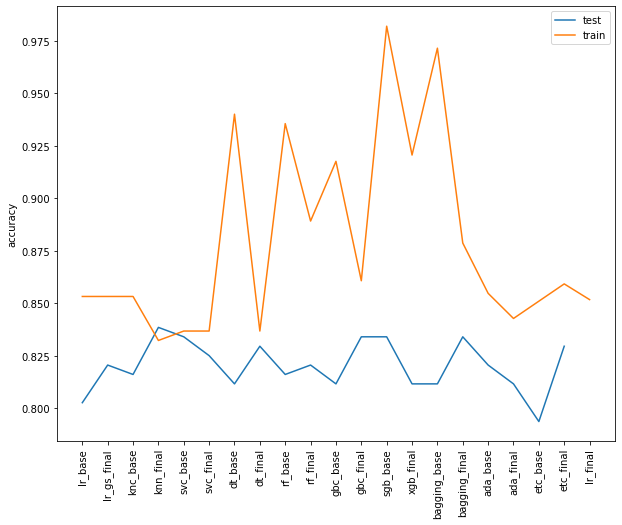

In [38]:
plot_metric_curves("accuracy")

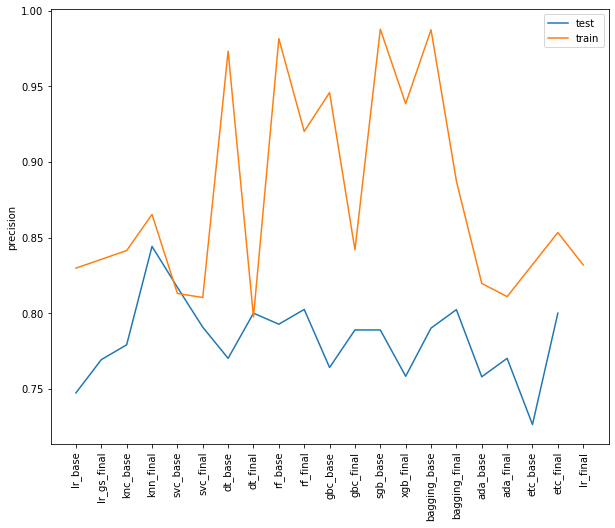

In [39]:
plot_metric_curves("precision")

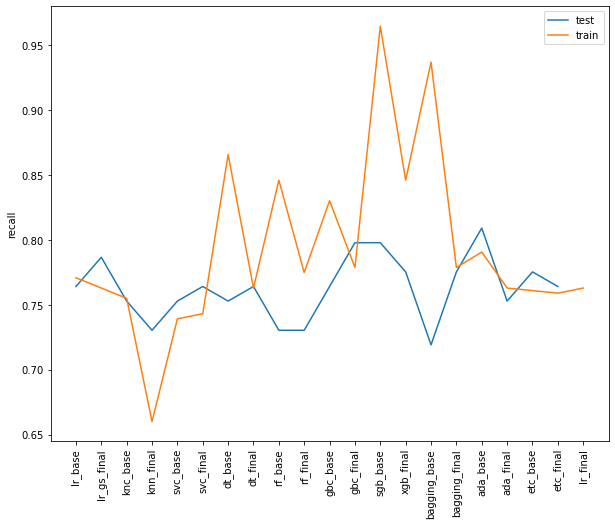

In [40]:
plot_metric_curves("recall")

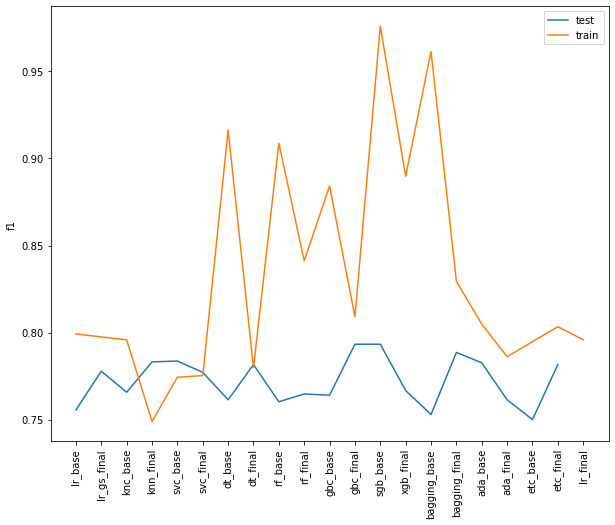

In [41]:
plot_metric_curves("f1")

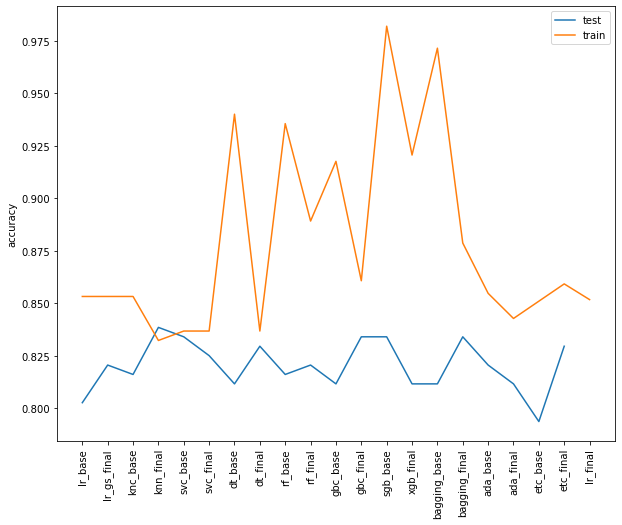

In [43]:
plot_metric_curves("accuracy")

Almost all of the above models are good. Let's use `VoteClassifier` to combine the models.

### One Final Model

In [44]:
model_params = shelve.open('model_params')

In [47]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, 
    ExtraTreesClassifier, BaggingClassifier, VotingClassifier)
from xgboost import XGBClassifier

In [58]:
vt_base = VotingClassifier(estimators = [('lr', LogisticRegression()), ('knn', KNeighborsClassifier()),
     ('dt', DecisionTreeClassifier()), ('rf', RandomForestClassifier()),
    ('ada', AdaBoostClassifier()), ('gb', GradientBoostingClassifier()),
    ('et', ExtraTreesClassifier()), ('bc', BaggingClassifier()), ('xgb', XGBClassifier())],
    voting = 'soft')

vt_base.fit(X_train, y_train)

C:\Users\harik\anaconda3\lib\site-packages\xgboost\sklearn.py:1224: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)


[16:27:46] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.5.1/src/learner.cc:1115: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'binary:logistic' was changed from 'error' to 'logloss'. Explicitly set eval_metric if you'd like to restore the old behavior.


VotingClassifier(estimators=[('lr', LogisticRegression()),
                             ('knn', KNeighborsClassifier()),
                             ('dt', DecisionTreeClassifier()),
                             ('rf', RandomForestClassifier()),
                             ('ada', AdaBoostClassifier()),
                             ('gb', GradientBoostingClassifier()),
                             ('et', ExtraTreesClassifier()),
                             ('bc', BaggingClassifier()),
                             ('xgb',
                              XGBClassifier(base_score=None, booster=None,
                                            colsample_bylevel=None,
                                            col...
                                            interaction_constraints=None,
                                            learning_rate=None,
                                            max_delta_step=None, max_depth=None,
                                            min_child_wei

In [61]:
evaluate_model(vt_base, 'vt_base', final = True)

{'accuracy': 0.820627802690583,
 'precision': 0.7752808988764045,
 'recall': 0.7752808988764045,
 'f1': 0.7752808988764045,
 'roc_auc': 0.8130135837665604}

In [62]:
evaluate_model(vt_base, 'vt_base', final = True, train = True,
    X = X_train, y = y_train)

{'accuracy': 0.9895209580838323,
 'precision': 0.9959677419354839,
 'recall': 0.9762845849802372,
 'f1': 0.9860279441117764,
 'roc_auc': 0.9869374732130103}

In [63]:
vt_base_2 = VotingClassifier(estimators = [('lr', LogisticRegression()), ('knn', KNeighborsClassifier()),
     ('dt', DecisionTreeClassifier()), ('rf', RandomForestClassifier()),
    ('ada', AdaBoostClassifier()), ('gb', GradientBoostingClassifier()),
    ('et', ExtraTreesClassifier()), ('bc', BaggingClassifier()), ('xgb', XGBClassifier())],
    voting = 'hard')

vt_base_2.fit(X_train, y_train)

C:\Users\harik\anaconda3\lib\site-packages\xgboost\sklearn.py:1224: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)


[16:29:34] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.5.1/src/learner.cc:1115: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'binary:logistic' was changed from 'error' to 'logloss'. Explicitly set eval_metric if you'd like to restore the old behavior.


VotingClassifier(estimators=[('lr', LogisticRegression()),
                             ('knn', KNeighborsClassifier()),
                             ('dt', DecisionTreeClassifier()),
                             ('rf', RandomForestClassifier()),
                             ('ada', AdaBoostClassifier()),
                             ('gb', GradientBoostingClassifier()),
                             ('et', ExtraTreesClassifier()),
                             ('bc', BaggingClassifier()),
                             ('xgb',
                              XGBClassifier(base_score=None, booster=None,
                                            colsample_bylevel=None,
                                            col...
                                            interaction_constraints=None,
                                            learning_rate=None,
                                            max_delta_step=None, max_depth=None,
                                            min_child_wei

In [64]:
evaluate_model(vt_base_2)

{'accuracy': 0.8295964125560538,
 'precision': 0.7802197802197802,
 'recall': 0.797752808988764,
 'f1': 0.7888888888888889,
 'roc_auc': 0.8242495388227402}

In [65]:
evaluate_model(vt_base_2, train = True, X = X_train, y = y_train)

{'accuracy': 0.9715568862275449,
 'precision': 0.9957627118644068,
 'recall': 0.9288537549407114,
 'f1': 0.9611451942740286,
 'roc_auc': 0.9632220581932474}

So, hard voting is douing better. Let's see if we can get better performance using the best parameters.

In [93]:
models = [LogisticRegression, KNeighborsClassifier, SVC, DecisionTreeClassifier,
    RandomForestClassifier, GradientBoostingClassifier, XGBClassifier,
    AdaBoostClassifier,BaggingClassifier, ExtraTreesClassifier]

In [75]:
i=1
params = []
for key, value in model_params.items():
    if i%2 ==0:
        params.append(value)
    i+=1

In [79]:
params[0]["solver"] = "saga"

In [179]:
models_with_params = []
for model, param in zip(models, params):
    model_name = model.__name__
    print(model_name)
    models_with_params.append((model_name, model(**param)))

LogisticRegression
KNeighborsClassifier
SVC
DecisionTreeClassifier
RandomForestClassifier
GradientBoostingClassifier
XGBClassifier
AdaBoostClassifier
BaggingClassifier
ExtraTreesClassifier


In [180]:
vt_base_3 = VotingClassifier(estimators = models_with_params, voting = 'hard')

vt_base_3.fit(X, y)

C:\Users\harik\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:329: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn("The max_iter was reached which means "
C:\Users\harik\anaconda3\lib\site-packages\xgboost\sklearn.py:1224: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)


[17:19:41] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.5.1/src/learner.cc:1115: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'binary:logistic' was changed from 'error' to 'logloss'. Explicitly set eval_metric if you'd like to restore the old behavior.


VotingClassifier(estimators=[('LogisticRegression',
                              LogisticRegression(C=1, l1_ratio=0.9,
                                                 penalty='elasticnet',
                                                 solver='saga')),
                             ('KNeighborsClassifier',
                              KNeighborsClassifier(n_neighbors=16, p=1)),
                             ('SVC', SVC(C=0.1, gamma=0.1)),
                             ('DecisionTreeClassifier',
                              DecisionTreeClassifier(max_depth=4,
                                                     min_samples_leaf=10)),
                             ('RandomForestClassifier',
                              RandomForestClassifier...
                             ('AdaBoostClassifier',
                              AdaBoostClassifier(learning_rate=0.1,
                                                 n_estimators=110)),
                             ('BaggingClassifier',
    

In [181]:
evaluate_model(vt_base_3)

{'accuracy': 0.8475336322869955,
 'precision': 0.8313253012048193,
 'recall': 0.7752808988764045,
 'f1': 0.8023255813953489,
 'roc_auc': 0.8354016434680529}

No improvement.

In [182]:
models_with_params.pop(2)

('SVC', SVC(C=0.1, gamma=0.1))

In [183]:
vt_base_4 = VotingClassifier(estimators = models_with_params, voting = 'soft')

vt_base_4.fit(X, y)
evaluate_model(vt_base_4)

C:\Users\harik\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:329: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn("The max_iter was reached which means "
C:\Users\harik\anaconda3\lib\site-packages\xgboost\sklearn.py:1224: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)


[17:20:06] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.5.1/src/learner.cc:1115: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'binary:logistic' was changed from 'error' to 'logloss'. Explicitly set eval_metric if you'd like to restore the old behavior.


{'accuracy': 0.8699551569506726,
 'precision': 0.8658536585365854,
 'recall': 0.797752808988764,
 'f1': 0.8304093567251462,
 'roc_auc': 0.8578316283749791}

In [176]:
evaluate_model(vt_base_3,final = True, model_name='vt_final')

{'accuracy': 0.852017937219731,
 'precision': 0.8333333333333334,
 'recall': 0.7865168539325843,
 'f1': 0.8092485549132948,
 'roc_auc': 0.841019620996143}

In [175]:
evaluate_model(vt_base_3, train = True, X = X_train, y = y_train)

{'accuracy': 0.8607784431137725,
 'precision': 0.8478260869565217,
 'recall': 0.7707509881422925,
 'f1': 0.8074534161490683,
 'roc_auc': 0.8432068193723511}

In [106]:
evaluate_model(vt_base_4, train = True, X = X_train, y = y_train)

{'accuracy': 0.8772455089820359,
 'precision': 0.8868778280542986,
 'recall': 0.7747035573122529,
 'f1': 0.8270042194092827,
 'roc_auc': 0.8572312967284156}

In [109]:
all_models = pd.DataFrame(models_performance).T

In [112]:
all_models

,accuracy,precision,recall,f1,roc_auc
lr_base,0.802691,0.747253,0.764045,0.755556,0.796202
lr_gs_final,0.820628,0.769231,0.786517,0.777778,0.814900
knc_base,0.816143,0.779070,0.752809,0.765714,0.805509
knn_final,0.838565,0.844156,0.730337,0.783133,0.820392
svc_base,0.834081,0.817073,0.752809,0.783626,0.820434
svc_final,0.825112,0.790698,0.764045,0.777143,0.814858
dt_base,0.811659,0.770115,0.752809,0.761364,0.801778
dt_final,0.829596,0.800000,0.764045,0.781609,0.818590
rf_base,0.816143,0.792683,0.730337,0.760234,0.801736
rf_final,0.820628,0.802469,0.730337,0.764706,0.805467


In terms of accuracy, `knn_final` is the best model, followed by `svc_base`.

In [114]:
models_with_params[1]

('KNeighborsClassifier', KNeighborsClassifier(n_neighbors=16, p=1))

In [148]:
knn_final = KNeighborsClassifier(n_neighbors=16, p=1)
knn_final.fit(X, y)
evaluate_model(knn_final)

{'accuracy': 0.8295964125560538,
 'precision': 0.8311688311688312,
 'recall': 0.7191011235955056,
 'f1': 0.7710843373493976,
 'roc_auc': 0.8110430991111857}

In [189]:
def create_submission(model, data = test):
    """
    Creates submission dataframe

    Parameters
    ----------
    model : model
        The model to be used to make predictions
    data : dataframe
        The dataframe to be used to make predictions

    Returns
    -------
    submission : dataframe
    """
    pred = model.predict(data)
    labels = pd.read_csv('test_passangerID.csv')
    submission = pd.concat([labels, pd.DataFrame(pred)], axis=1)
    submission.columns = ['PassengerId', 'Survived']
    return submission

In [193]:
submission_5 = create_submission(vt_base_3)

In [194]:
submission_5["Survived"].sum()

162

In [195]:
submission_5.to_csv('submission_4.csv', index = False)

In [142]:
board = pd.read_csv(r"C:\Users\harik\Downloads\titanic-publicleaderboard.csv")

In [160]:
board[board["TeamName"].apply(lambda x: 'Hari' in x)]

,TeamId,TeamName,SubmissionDate,Score
1135,7787060,Harish Utgikar,2021-12-30 19:37:03,0.79186
2346,7970797,Harikesh Kumar #2,2022-01-06 11:34:01,0.78468
5624,7805285,Hari Harsha,2021-11-29 02:07:47,0.77511
7099,7927937,SakthiHarishDT,2021-12-24 14:25:15,0.77511
7300,6556444,Dody Harianto,2021-12-31 08:05:55,0.77511
8434,2894828,Hari Hara Sudhan,2022-01-05 07:56:38,0.77272
9263,6466960,Vladimir Haritonov,2021-12-13 17:51:34,0.76794
9525,7702150,Harine Ramesh,2021-11-10 14:16:09,0.76555
11011,7899312,Haris Irfan,2021-12-17 16:28:39,0.76315
12011,7823753,Hari Prakash G,2021-12-02 06:02:43,0.75119


In [162]:
sub1 = pd.read_csv('submission_1.csv')
sub2 = pd.read_csv('submission_2.csv')

In [165]:
sub2[sub1["Survived"] != sub2["Survived"]]

,PassengerId,Survived
4,896,0
32,924,0
36,928,0
50,942,1
53,945,0
90,982,1
165,1057,0
181,1073,1
202,1094,1
236,1128,0
